# Scoliosis Progression Risk Detection — Exploratory analysis
Data: local `msd_risk_dataset.xlsx`. Modeling is in `.py` files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

In [2]:
# Local data (msd_risk_dataset.xlsx in repo root or in data/)
DATA_PATH = Path("msd_risk_dataset.xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("data") / "msd_risk_dataset.xlsx"

In [3]:
df = pd.read_excel(DATA_PATH)
df.head(2)

,Age,Gender,Height,Weight,Pain_Score,Backpack_Weight,Backpack_Height,Daily_Load_Duration,Backpack_Position,Neutral_Cervical_Curve,...,Neutral_Shoulder_Alignment,Neutral_Head_Tilt,Cervical_Deviation,Thoracic_Deviation,Lumbar_Deviation,Pelvic_Tilt_Deviation,CVA_Deviation,Shoulder_Deviation,Head_Tilt_Deviation,MSD_Risk_Level
0,18,Female,170.63,55.85,1,4.29,69.99,60,between the shoulder blades and lower back,23.67,...,0.25,0.83,1.08,0.62,0.6,0.72,2.45,0.08,0.40,Low
1,6,Male,128.00,33.17,1,3.39,43.21,45,between the shoulder blades and lower back,38.81,...,1.73,-0.81,0.92,1.67,1.2,0.43,1.80,0.51,0.39,High


In [4]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset:
(21652, 24)

Column names:
Index(['Age', 'Gender', 'Height', 'Weight', 'Pain_Score', 'Backpack_Weight',
       'Backpack_Height', 'Daily_Load_Duration', 'Backpack_Position',
       'Neutral_Cervical_Curve', 'Neutral_Thoracic_Curve',
       'Neutral_Lumbar_Curve', 'Neutral_Pelvic_Tilt', 'Neutral_CVA',
       'Neutral_Shoulder_Alignment', 'Neutral_Head_Tilt', 'Cervical_Deviation',
       'Thoracic_Deviation', 'Lumbar_Deviation', 'Pelvic_Tilt_Deviation',
       'CVA_Deviation', 'Shoulder_Deviation', 'Head_Tilt_Deviation',
       'MSD_Risk_Level'],
      dtype='str')

First 5 rows:


,Age,Gender,Height,Weight,Pain_Score,Backpack_Weight,Backpack_Height,Daily_Load_Duration,Backpack_Position,Neutral_Cervical_Curve,...,Neutral_Shoulder_Alignment,Neutral_Head_Tilt,Cervical_Deviation,Thoracic_Deviation,Lumbar_Deviation,Pelvic_Tilt_Deviation,CVA_Deviation,Shoulder_Deviation,Head_Tilt_Deviation,MSD_Risk_Level
0,18,Female,170.63,55.85,1,4.29,69.99,60,between the shoulder blades and lower back,23.67,...,0.25,0.83,1.08,0.62,0.60,0.72,2.45,0.08,0.40,Low
1,6,Male,128.00,33.17,1,3.39,43.21,45,between the shoulder blades and lower back,38.81,...,1.73,-0.81,0.92,1.67,1.20,0.43,1.80,0.51,0.39,High
2,18,Female,176.73,62.51,3,4.12,46.59,15,on the buttocks or significantly low,28.27,...,0.16,-0.64,3.94,0.11,3.84,0.23,2.31,0.61,0.04,Low
3,11,Female,145.45,39.39,0,6.26,44.68,75,slightly lower on the back,26.32,...,-0.38,-1.23,4.16,0.50,0.15,1.01,2.59,0.50,1.09,High
4,12,Male,145.61,43.54,1,6.62,39.14,60,slightly lower on the back,29.05,...,1.29,-0.51,3.59,5.76,4.71,0.82,3.99,1.63,0.07,Medium


In [5]:
print("\nData types:")
print(df.dtypes)


Data types:
Age                             int64
Gender                            str
Height                        float64
Weight                        float64
Pain_Score                      int64
Backpack_Weight               float64
Backpack_Height               float64
Daily_Load_Duration             int64
Backpack_Position                 str
Neutral_Cervical_Curve        float64
Neutral_Thoracic_Curve        float64
Neutral_Lumbar_Curve          float64
Neutral_Pelvic_Tilt           float64
Neutral_CVA                   float64
Neutral_Shoulder_Alignment    float64
Neutral_Head_Tilt             float64
Cervical_Deviation            float64
Thoracic_Deviation            float64
Lumbar_Deviation              float64
Pelvic_Tilt_Deviation         float64
CVA_Deviation                 float64
Shoulder_Deviation            float64
Head_Tilt_Deviation           float64
MSD_Risk_Level                    str
dtype: object


In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Age                           0
Gender                        0
Height                        0
Weight                        0
Pain_Score                    0
Backpack_Weight               0
Backpack_Height               0
Daily_Load_Duration           0
Backpack_Position             0
Neutral_Cervical_Curve        0
Neutral_Thoracic_Curve        0
Neutral_Lumbar_Curve          0
Neutral_Pelvic_Tilt           0
Neutral_CVA                   0
Neutral_Shoulder_Alignment    0
Neutral_Head_Tilt             0
Cervical_Deviation            0
Thoracic_Deviation            0
Lumbar_Deviation              0
Pelvic_Tilt_Deviation         0
CVA_Deviation                 0
Shoulder_Deviation            0
Head_Tilt_Deviation           0
MSD_Risk_Level                0
dtype: int64


In [7]:
print("\nStatistical summary:")
display(df.describe())


Statistical summary:


,Age,Height,Weight,Pain_Score,Backpack_Weight,Backpack_Height,Daily_Load_Duration,Neutral_Cervical_Curve,Neutral_Thoracic_Curve,Neutral_Lumbar_Curve,...,Neutral_CVA,Neutral_Shoulder_Alignment,Neutral_Head_Tilt,Cervical_Deviation,Thoracic_Deviation,Lumbar_Deviation,Pelvic_Tilt_Deviation,CVA_Deviation,Shoulder_Deviation,Head_Tilt_Deviation
count,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,...,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000,21652.000000
mean,11.976215,146.029518,38.935468,1.907445,4.674404,43.751264,41.897053,29.704658,34.974276,29.727958,...,55.006598,0.006904,-0.000421,2.685982,2.665907,2.669745,1.346708,2.415054,0.672145,0.670022
std,3.745844,15.607890,9.248036,2.383574,1.947592,8.670752,21.388948,4.735664,4.973769,4.708372,...,1.995608,0.990376,1.003027,1.778877,1.769238,1.778023,0.893658,1.216827,0.448080,0.447063
min,6.000000,120.000000,25.000000,0.000000,0.000000,11.380000,15.000000,11.710000,15.080000,11.660000,...,45.680000,-3.870000,-4.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,132.890000,31.450000,0.000000,3.280000,37.700000,30.000000,26.490000,31.640000,26.560000,...,53.670000,-0.660000,-0.670000,1.250000,1.220000,1.230000,0.620000,1.540000,0.310000,0.310000
50%,12.000000,145.720000,37.950000,1.000000,4.440000,43.360000,30.000000,29.830000,34.990000,29.870000,...,55.010000,0.000000,0.000000,2.460000,2.440000,2.440000,1.230000,2.380000,0.610000,0.610000
75%,15.000000,158.970000,45.480000,3.000000,5.840000,49.380000,60.000000,33.130000,38.350000,33.110000,...,56.350000,0.670000,0.670000,3.860000,3.830000,3.840000,1.940000,3.250000,0.970000,0.970000
max,18.000000,180.000000,80.000000,10.000000,15.130000,80.280000,90.000000,39.990000,49.920000,40.000000,...,64.220000,4.070000,4.190000,11.430000,11.000000,10.490000,5.300000,7.530000,3.000000,2.560000


MSD_Risk_Level
Low       8745
Medium    6469
High      6438
Name: count, dtype: int64


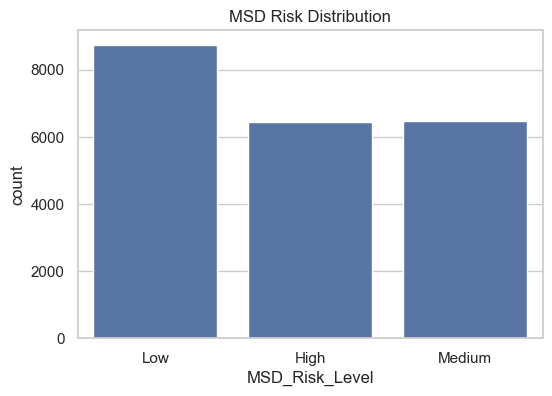

In [8]:
target_col = "MSD_Risk_Level"

print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("MSD Risk Distribution")
plt.show()

MSD_Risk_Level
Low       8745
Medium    6469
High      6438
Name: count, dtype: int64


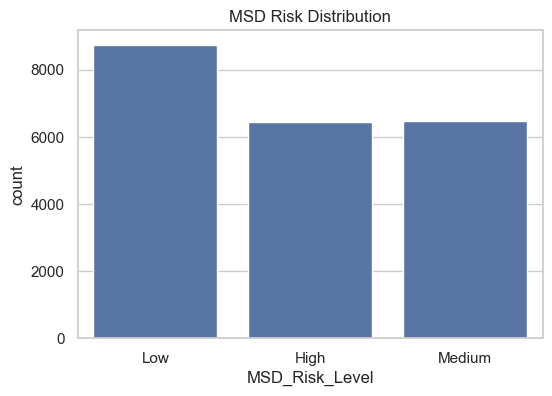

In [9]:
target_col = "MSD_Risk_Level"

print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("MSD Risk Distribution")
plt.show()

## Variable groups
Define numeric vs categorical columns for the rest of the analysis.

In [10]:
TARGET = "MSD_Risk_Level"
CAT_COLS = ["Gender", "Backpack_Position"]
NUM_COLS = [c for c in df.columns if c not in CAT_COLS and c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
DEMO_NUM = ["Age", "Height", "Weight", "Pain_Score", "Backpack_Weight", "Backpack_Height", "Daily_Load_Duration"]
CURVE_COLS = [c for c in NUM_COLS if "Curve" in c or "Deviation" in c or "CVA" in c or "Shoulder" in c or "Head_Tilt" in c or "Pelvic" in c]
print("Categorical:", CAT_COLS)
print("Numeric (demo/lifestyle):", DEMO_NUM)
print("Numeric (posture/curves):", CURVE_COLS[:6], "...")

Categorical: ['Gender', 'Backpack_Position']
Numeric (demo/lifestyle): ['Age', 'Height', 'Weight', 'Pain_Score', 'Backpack_Weight', 'Backpack_Height', 'Daily_Load_Duration']
Numeric (posture/curves): ['Neutral_Cervical_Curve', 'Neutral_Thoracic_Curve', 'Neutral_Lumbar_Curve', 'Neutral_Pelvic_Tilt', 'Neutral_CVA', 'Neutral_Shoulder_Alignment'] ...


## Categorical variables
Distribution of Gender and Backpack_Position.

/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/593883125.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", ax=axes[0], palette="viridis")
/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/593883125.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Backpack_Position", ax=axes[1], palette="viridis")


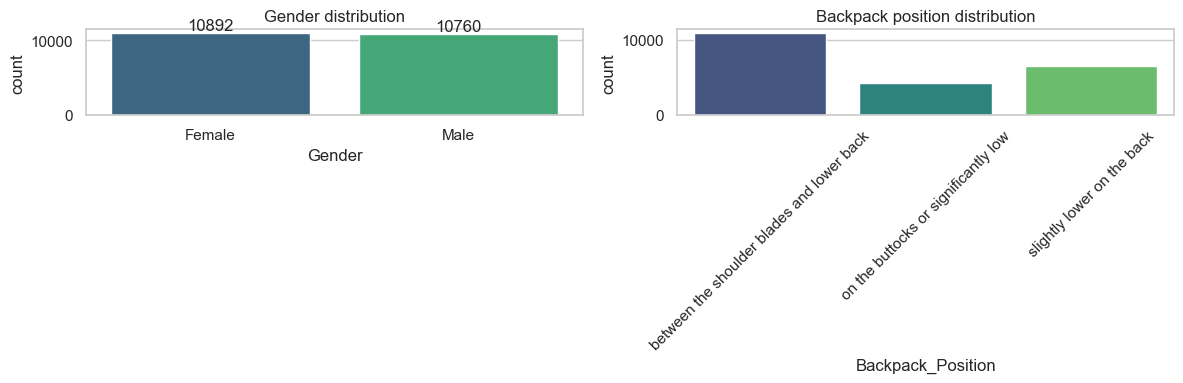


Backpack_Position value counts:
Backpack_Position
between the shoulder blades and lower back    10818
slightly lower on the back                     6528
on the buttocks or significantly low           4306
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Gender", ax=axes[0], palette="viridis")
axes[0].set_title("Gender distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2., p.get_height()), ha="center", va="bottom")
sns.countplot(data=df, x="Backpack_Position", ax=axes[1], palette="viridis")
axes[1].set_title("Backpack position distribution")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("\nBackpack_Position value counts:")
print(df["Backpack_Position"].value_counts())

## Numeric distributions (demographics & lifestyle)
Histograms for age, height, weight, pain score, backpack load, and load duration.

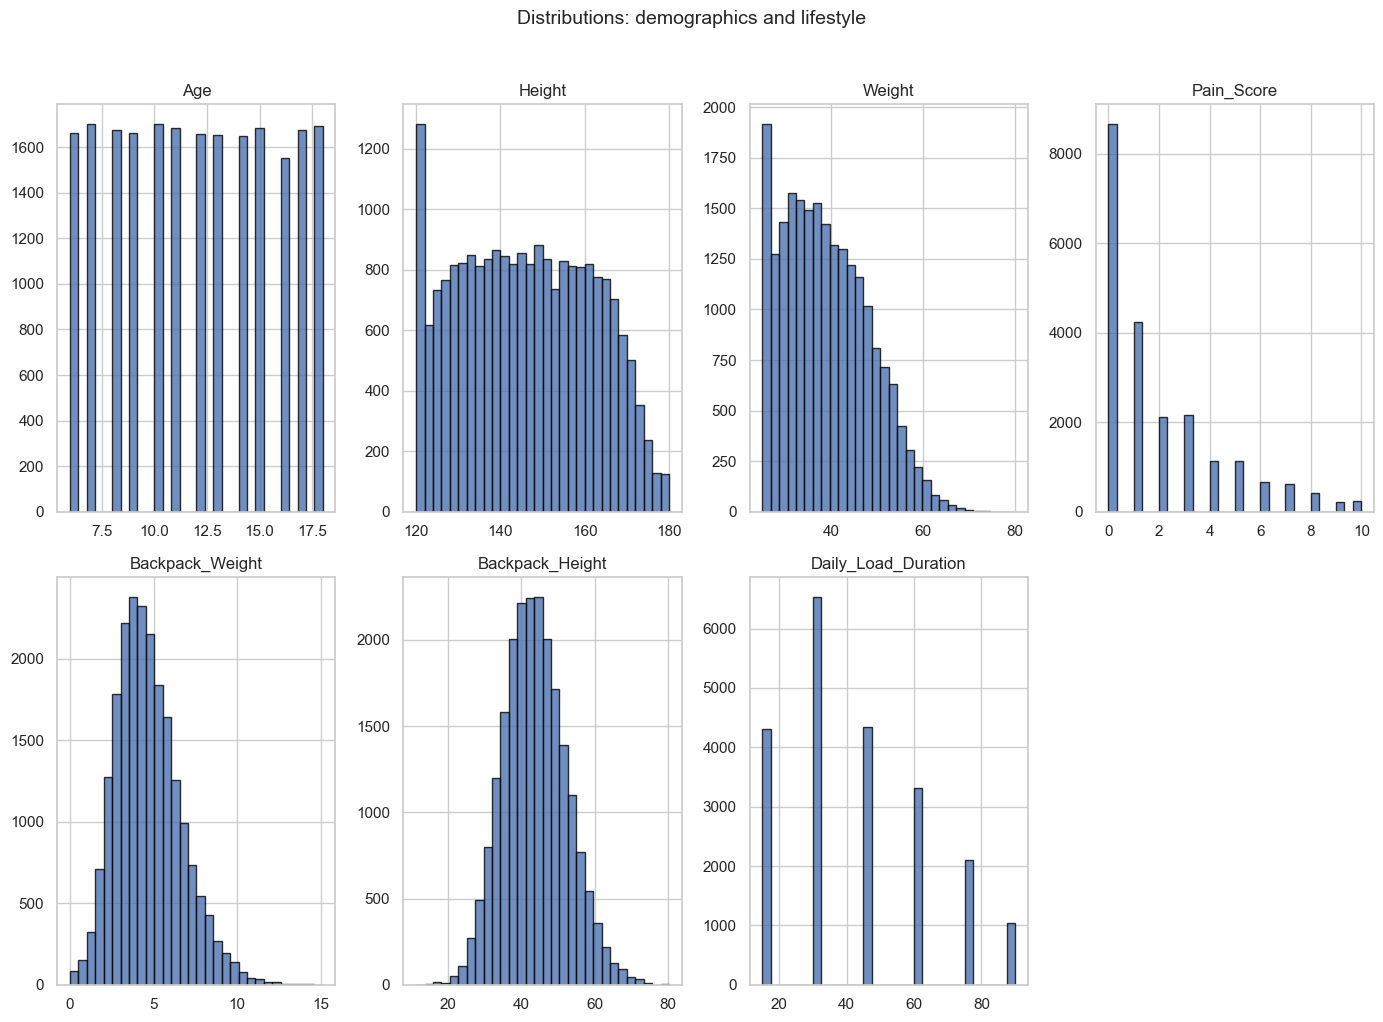

In [12]:
df[DEMO_NUM].hist(bins=30, figsize=(14, 10), layout=(2, 4), edgecolor="black", alpha=0.8)
plt.suptitle("Distributions: demographics and lifestyle", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Posture and spinal curves
Neutral curves (cervical, thoracic, lumbar) and deviation measures.

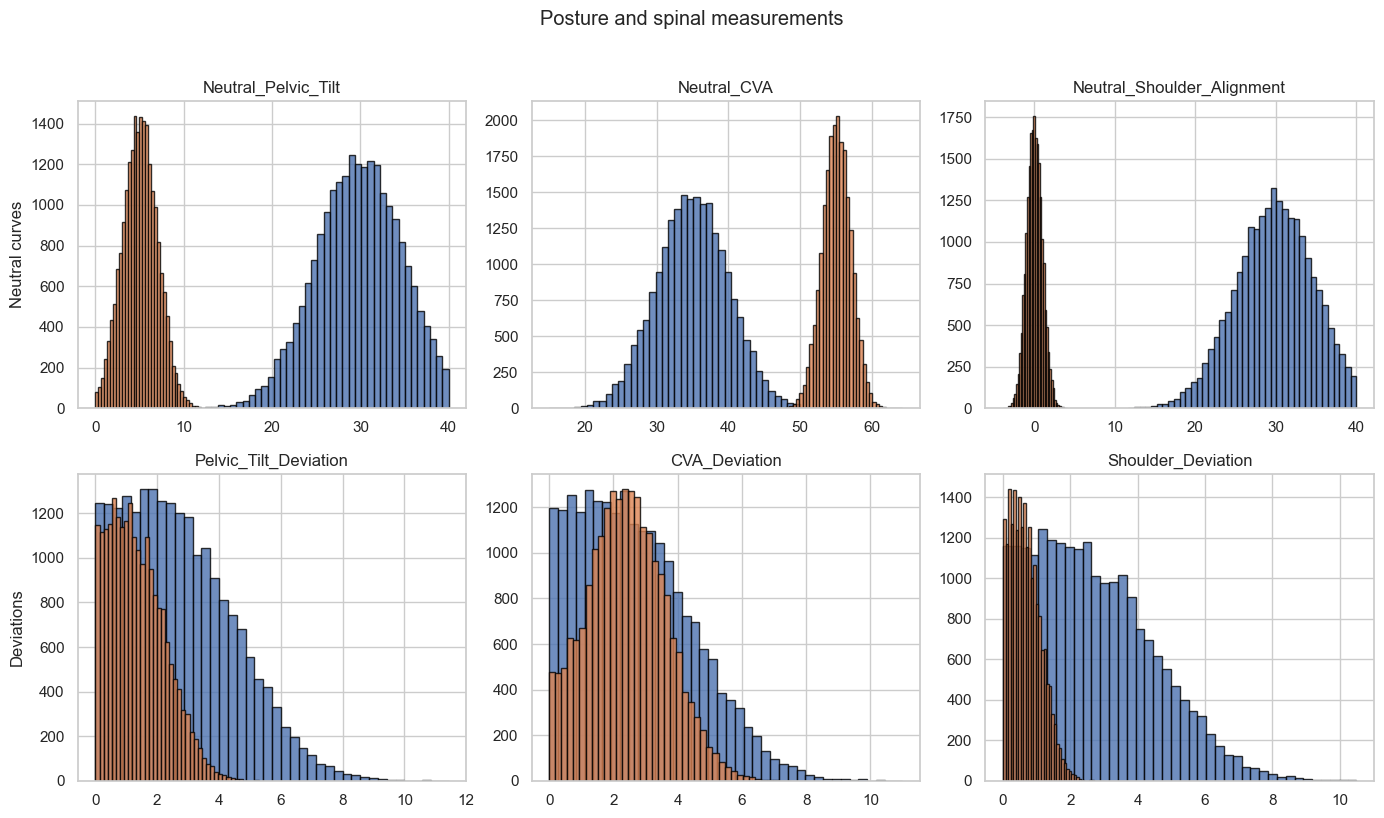

In [13]:
neutral = [c for c in CURVE_COLS if "Neutral" in c]
deviation = [c for c in CURVE_COLS if "Deviation" in c]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(neutral[:6]):
    ax = axes[0, i % 3]
    df[col].hist(bins=40, ax=ax, edgecolor="black", alpha=0.8)
    ax.set_title(col)
axes[0, 0].set_ylabel("Neutral curves")
for i, col in enumerate(deviation[:6]):
    ax = axes[1, i % 3]
    df[col].hist(bins=40, ax=ax, edgecolor="black", alpha=0.8)
    ax.set_title(col)
axes[1, 0].set_ylabel("Deviations")
plt.suptitle("Posture and spinal measurements", y=1.02)
plt.tight_layout()
plt.show()

## Target vs categorical
MSD risk level by Gender and by Backpack_Position.

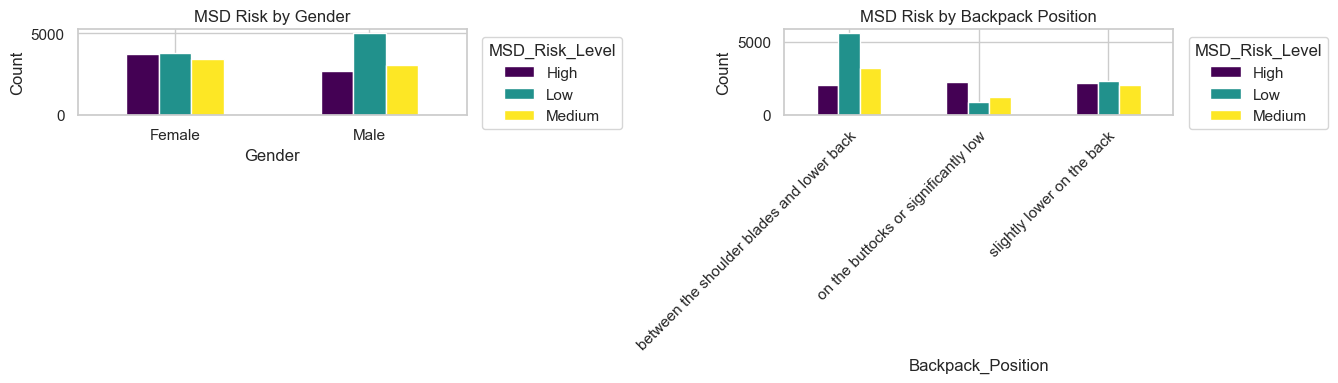


Risk proportion by Gender:
MSD_Risk_Level   High    Low  Medium
Gender                              
Female          0.342  0.346   0.312
Male            0.252  0.463   0.285


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df["Gender"], df[TARGET]).plot(kind="bar", ax=axes[0], stacked=False, colormap="viridis")
axes[0].set_title("MSD Risk by Gender")
axes[0].set_ylabel("Count")
axes[0].legend(title=TARGET, bbox_to_anchor=(1.02, 1))
axes[0].tick_params(axis="x", rotation=0)
ct = pd.crosstab(df["Backpack_Position"], df[TARGET])
ct.plot(kind="bar", ax=axes[1], stacked=False, colormap="viridis")
axes[1].set_title("MSD Risk by Backpack Position")
axes[1].set_ylabel("Count")
axes[1].legend(title=TARGET, bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis="x", rotation=45)
plt.setp(axes[1].get_xticklabels(), ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()
# Proportions within each group
print("\nRisk proportion by Gender:")
print(pd.crosstab(df["Gender"], df[TARGET], normalize="index").round(3))

## Target vs key numeric features
How Age, Pain_Score, Backpack_Weight, and Daily_Load_Duration differ across MSD risk levels.

/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/1488214482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/1488214482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/1488214482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette="Set2")
/var/folders/x3/

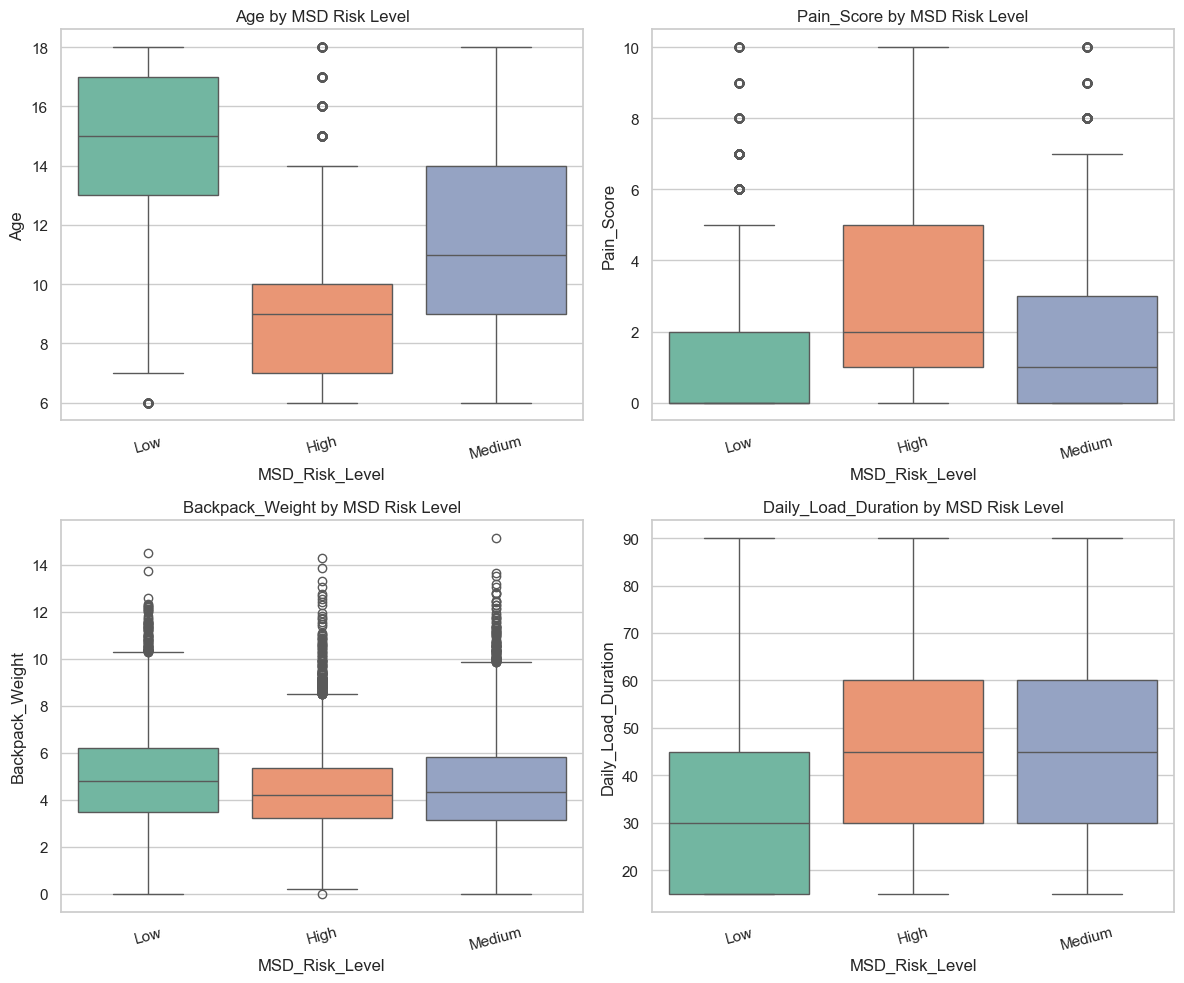

In [15]:
key_num = ["Age", "Pain_Score", "Backpack_Weight", "Daily_Load_Duration"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flat, key_num):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} by MSD Risk Level")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Target vs posture (violin)
Spinal deviations and neutral curves by risk level.

/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/2151098588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, ax=ax, palette="muted")
/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/2151098588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, ax=ax, palette="muted")
/var/folders/x3/46y415w94f1bbjkccq6rrxlc0000gn/T/ipykernel_31256/2151098588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=TARGET, y=col, ax=ax, palette="muted")
/var

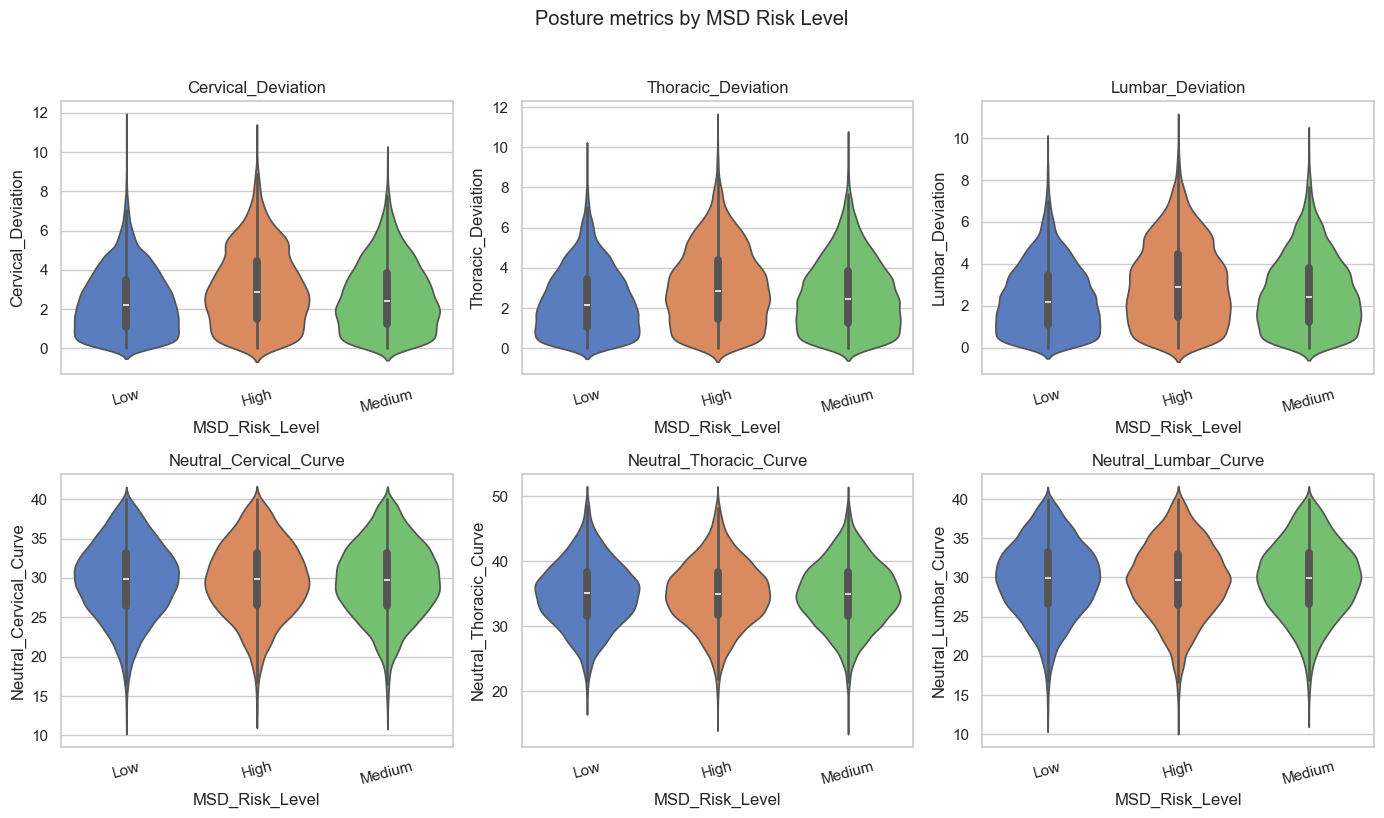

In [16]:
key_curve = ["Cervical_Deviation", "Thoracic_Deviation", "Lumbar_Deviation", "Neutral_Cervical_Curve", "Neutral_Thoracic_Curve", "Neutral_Lumbar_Curve"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, key_curve):
    sns.violinplot(data=df, x=TARGET, y=col, ax=ax, palette="muted")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Posture metrics by MSD Risk Level", y=1.02)
plt.tight_layout()
plt.show()

## Correlation heatmap (numeric features)
Correlations among numeric columns; strong correlations may inform feature selection.

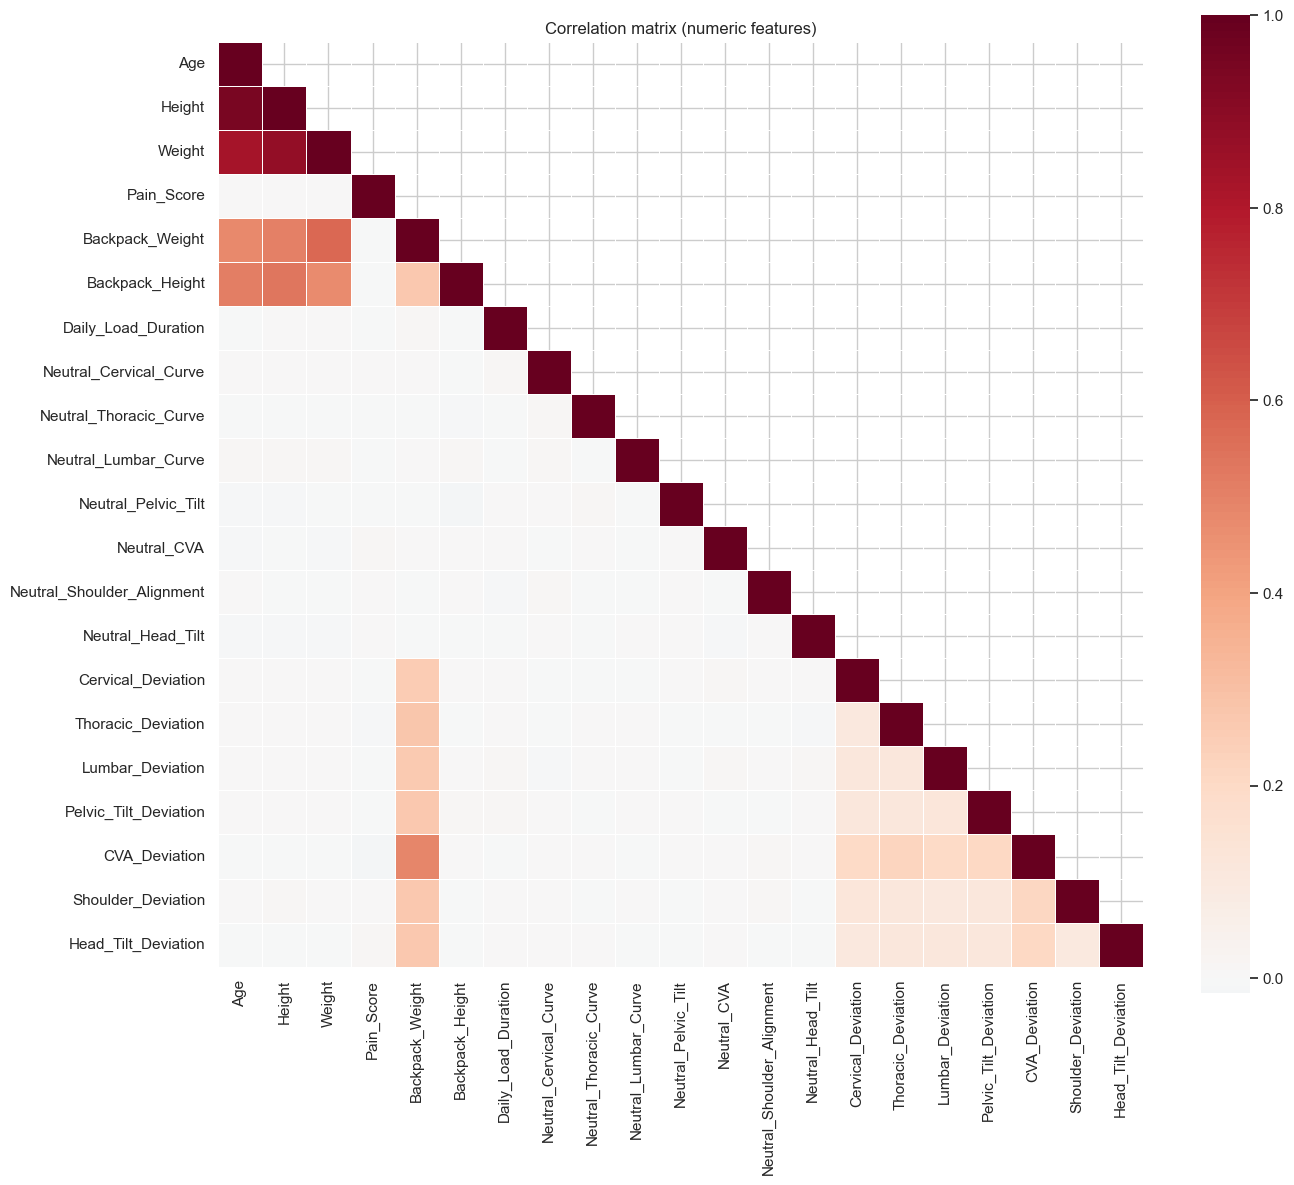

Strongest correlations (absolute):
Age              Height             0.948913
Height           Age                0.948913
Weight           Height             0.880232
Height           Weight             0.880232
Age              Weight             0.832571
Weight           Age                0.832571
Backpack_Weight  Weight             0.573068
Weight           Backpack_Weight    0.573068
Backpack_Height  Height             0.538489
Height           Backpack_Height    0.538489
Backpack_Height  Age                0.511130
Age              Backpack_Height    0.511130
Height           Backpack_Weight    0.505805
Backpack_Weight  Height             0.505805
CVA_Deviation    Backpack_Weight    0.489187
dtype: float64


In [17]:
corr = df[NUM_COLS].corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=False, square=True, linewidths=0.5)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()
# Top pairwise correlations (excluding diagonal)
corr_flat = corr.unstack()
corr_flat = corr_flat[corr_flat.index.get_level_values(0) != corr_flat.index.get_level_values(1)]
corr_flat = corr_flat.reindex(corr_flat.abs().sort_values(ascending=False).index)
print("Strongest correlations (absolute):")
print(corr_flat.head(15))

## Pain score and risk
Pain_Score distribution overall and by MSD risk level.

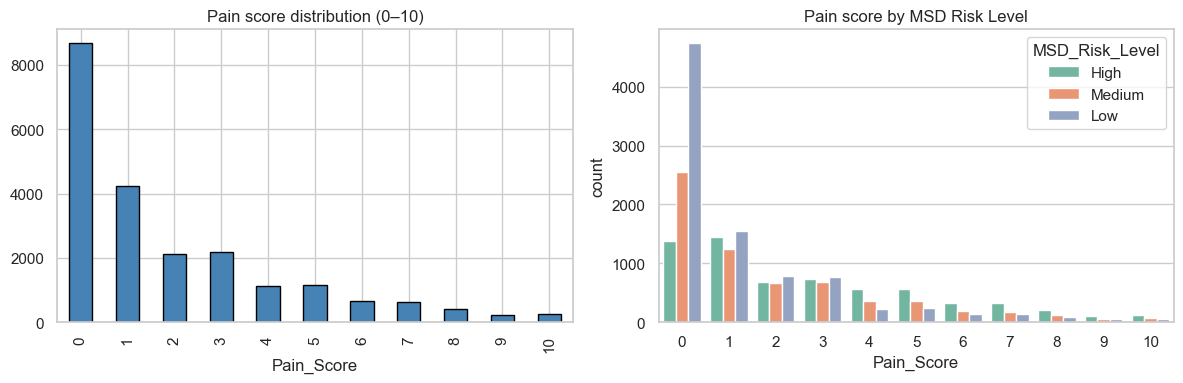


Mean Pain_Score by risk level:
                    mean       std  count
MSD_Risk_Level                           
High            2.805840  2.625365   6438
Low             1.246198  1.969197   8745
Medium          1.907250  2.349830   6469


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Pain_Score"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Pain score distribution (0–10)")
axes[0].set_xlabel("Pain_Score")
sns.countplot(data=df, x="Pain_Score", hue=TARGET, ax=axes[1], palette="Set2")
axes[1].set_title("Pain score by MSD Risk Level")
plt.tight_layout()
plt.show()
print("\nMean Pain_Score by risk level:")
print(df.groupby(TARGET)["Pain_Score"].agg(["mean", "std", "count"]))

## Height vs Weight by risk
Scatter plot colored by MSD risk level (sample for readability).

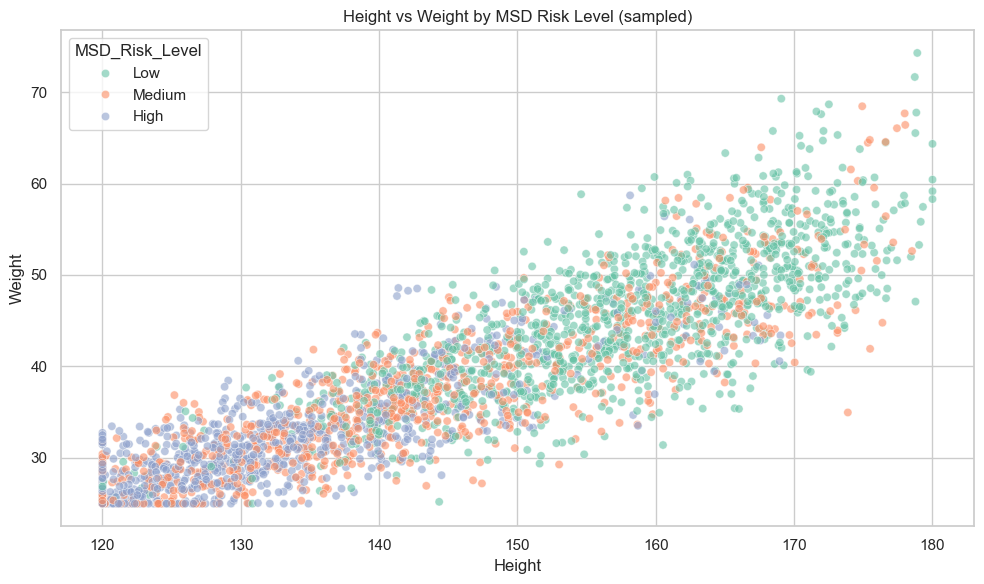

In [19]:
# Sample for clearer scatter (optional: remove .sample() to plot all points)
plot_df = df.sample(min(3000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="Height", y="Weight", hue=TARGET, alpha=0.6, palette="Set2")
plt.title("Height vs Weight by MSD Risk Level (sampled)")
plt.legend(title=TARGET)
plt.tight_layout()
plt.show()

## Pairplot: key predictors and target
Selected numeric features vs each other, colored by MSD risk (sample).

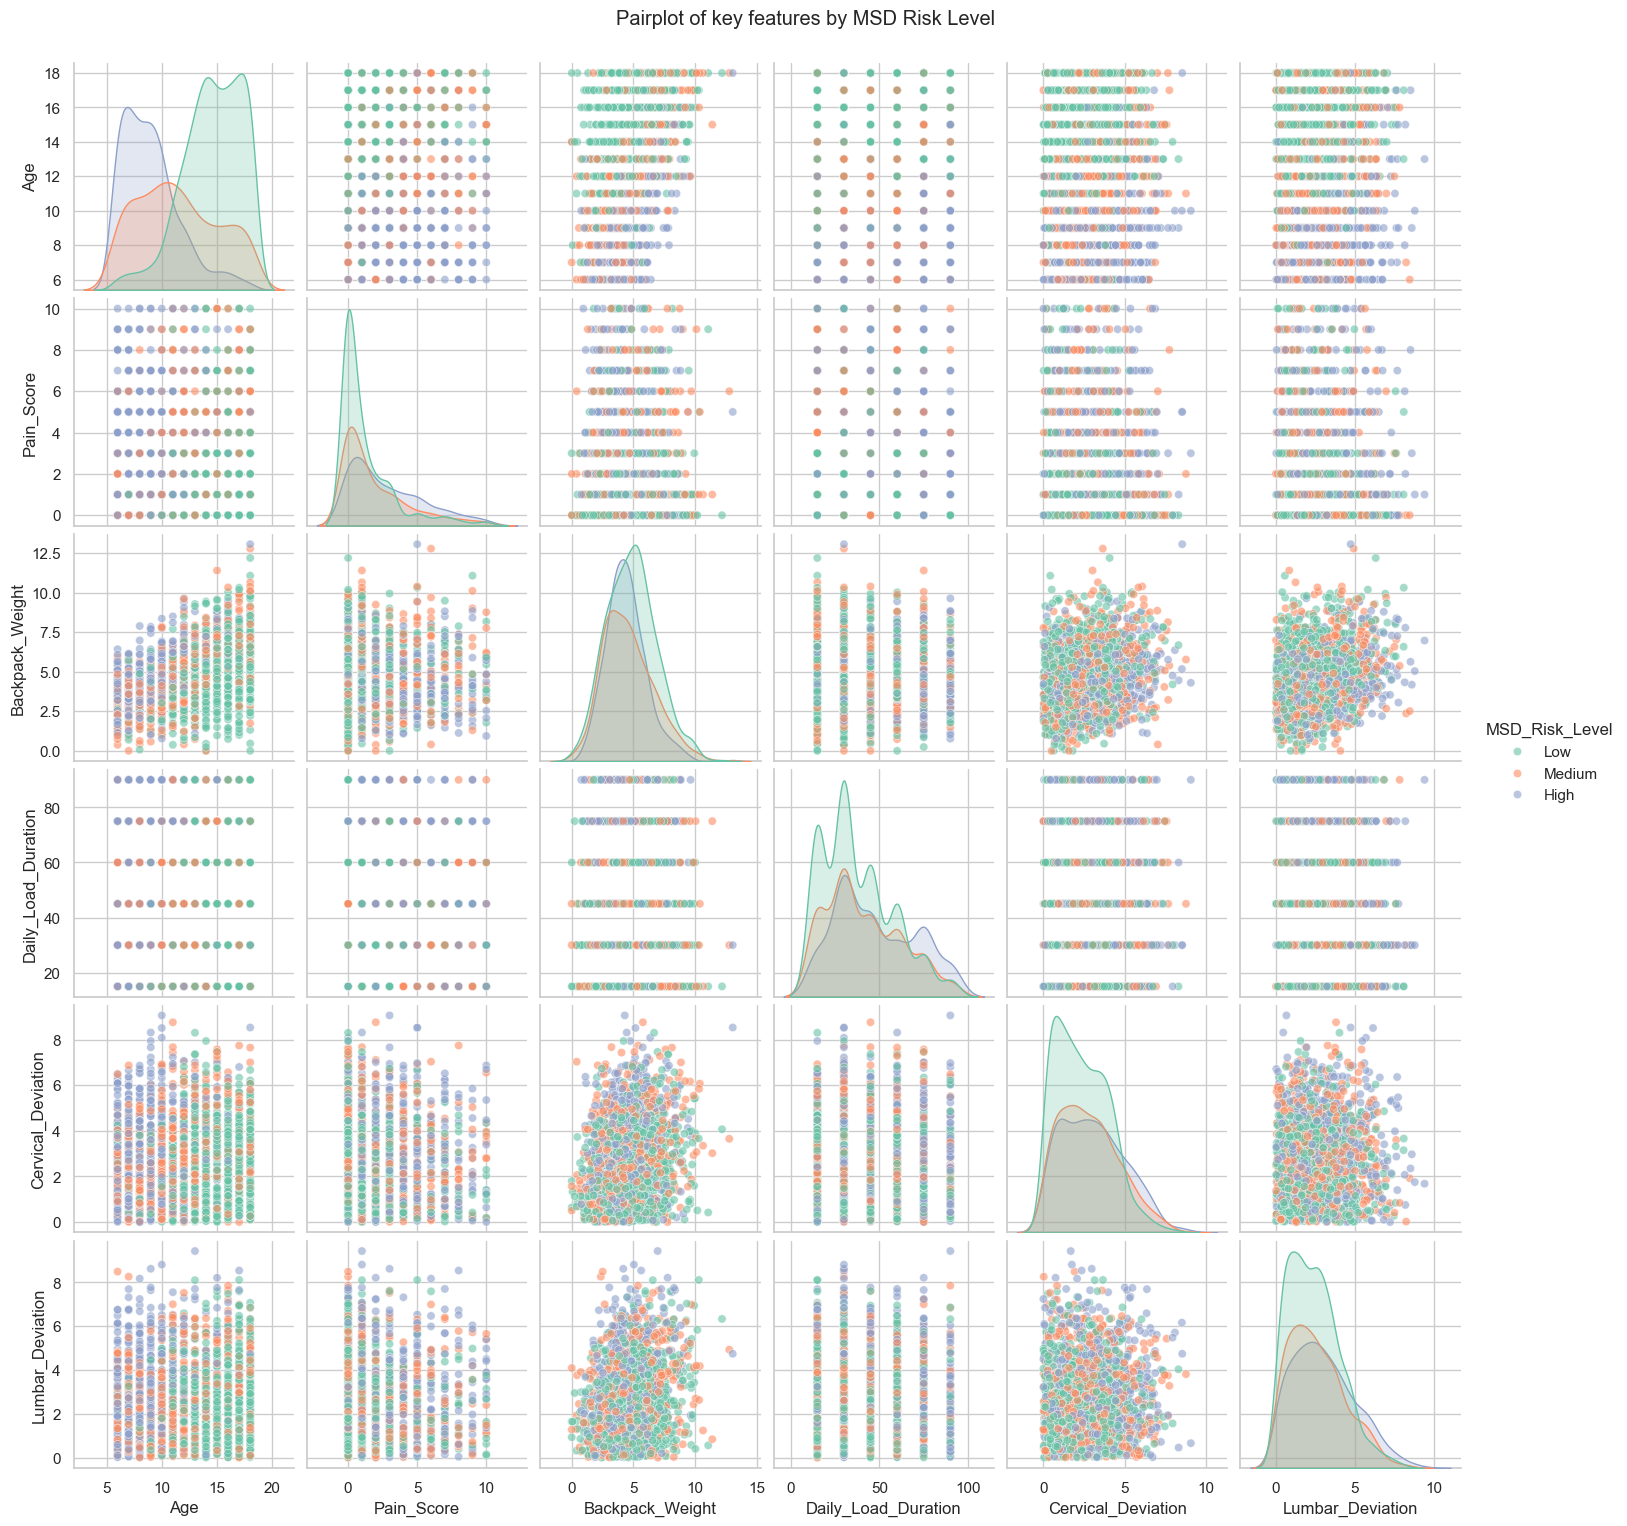

In [20]:
pair_cols = ["Age", "Pain_Score", "Backpack_Weight", "Daily_Load_Duration", "Cervical_Deviation", "Lumbar_Deviation", TARGET]
pair_df = df[pair_cols].sample(min(2000, len(df)), random_state=42)
g = sns.pairplot(pair_df, hue=TARGET, palette="Set2", diag_kind="kde", plot_kws={"alpha": 0.6})
g.fig.suptitle("Pairplot of key features by MSD Risk Level", y=1.02)
plt.show()

## Summary statistics by risk level
Mean of key numeric features for each MSD risk level.

In [21]:
summary = df.groupby(TARGET)[NUM_COLS].mean().T.round(3)
display(summary)
print("\nInterpretation: compare row values across Low / Medium / High to see which features differ most by risk.")

MSD_Risk_Level,High,Low,Medium
Age,9.034,14.590,11.371
Height,133.762,156.974,143.443
Weight,32.289,45.040,37.298
Pain_Score,2.806,1.246,1.907
Backpack_Weight,4.409,4.918,4.609
Backpack_Height,40.935,46.266,43.155
Daily_Load_Duration,46.664,38.197,42.155
Neutral_Cervical_Curve,29.729,29.712,29.671
Neutral_Thoracic_Curve,34.993,34.995,34.928
Neutral_Lumbar_Curve,29.572,29.821,29.758



Interpretation: compare row values across Low / Medium / High to see which features differ most by risk.


---
## Strongest Predictors of Scoliosis Risk

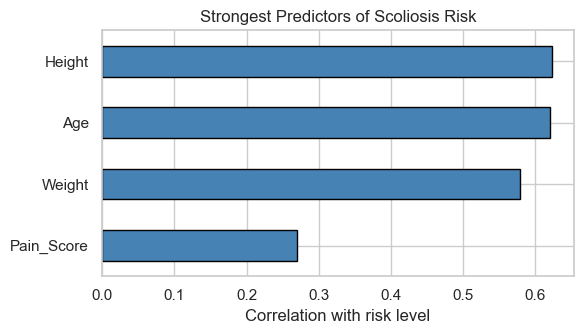

Saved: plot_top_predictors.png


In [27]:
# 2. Strongest predictors of MSD risk (correlation with risk level)
risk_enc = df[TARGET].map(risk_order)
numeric_only = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
corr_with_risk = df[numeric_only].corrwith(risk_enc).abs().sort_values(ascending=True).tail(4)
plt.figure(figsize=(6, 3.5))
corr_with_risk.plot(kind="barh", color="steelblue", edgecolor="black")
plt.xlabel("Correlation with risk level")
plt.title("Strongest Predictors of Scoliosis Risk")
plt.tight_layout()
plt.savefig("plot_top_predictors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_top_predictors.png")

---
## Summary of findings: what the data tells us

### Dataset and target
- **21,652 students**, 24 columns, **no missing values**. Target is **MSD_Risk_Level** (Low / Medium / High).
- Risk is **roughly balanced**: Low ~40%, Medium ~30%, High ~30%. No severe class imbalance for modeling.

### Demographics and lifestyle vs risk
- **Age**: High-risk group is **younger** (mean ~9 yr) than Low-risk (~14.6 yr). Suggests younger students are more often classified as high MSD risk, possibly due to posture/load relative to body size or still-developing posture.
- **Height & weight**: High risk is associated with **shorter** and **lighter** individuals; Low risk with older, taller, heavier. Consistent with age: the high-risk segment is largely school-age children.
- **Pain_Score**: **Clearly higher for High risk** (~2.8) than for Low (~1.2). Pain is a strong candidate predictor and may reflect both load and posture.
- **Backpack**: Backpack_Weight and Backpack_Height are **slightly** lower in the High-risk group, while **Daily_Load_Duration is longer** for High risk (~47 min vs ~38 min for Low). So **duration of load** matters more than weight/height in this sample.
- **Backpack_Position** and **Gender** both show differences in risk distribution in the crosstabs; worth including as categorical features.

### Posture and spinal measures
- **Neutral curves** (cervical, thoracic, lumbar, CVA, etc.) are **very similar** across risk levels—means are close. They describe “baseline” posture and do not separate risk groups much.
- **Deviations** (from neutral) **do separate risk levels**:  
  - **Cervical, thoracic, lumbar, and CVA deviations** are **higher for High risk** and **lowest for Low risk** (e.g. Cervical_Deviation ~3.08 vs ~2.41).  
  - Pelvic_Tilt_Deviation, Shoulder_Deviation, Head_Tilt_Deviation follow the same pattern (higher deviation → higher risk).
- **Takeaway**: Risk is more strongly linked to **postural deviation** (how far from neutral) than to the neutral posture itself. Deviation features are strong candidates for the model.

### Correlations and redundancy
- The **correlation heatmap** shows groups of highly correlated variables (e.g. deviations with each other, Height/Weight/Age). For modeling, consider **feature selection or regularization** to avoid redundancy and overfitting; possibly **PCA or a small subset of deviation + lifestyle** features.

### Implications for modeling
1. **Strong candidate features**: Pain_Score, Daily_Load_Duration, all **deviation** columns, Age (or Height/Weight as proxies), Gender, Backpack_Position.
2. **Weak discriminators**: Neutral curve measures add little; they can be dropped or deprioritized if the model is too large.
3. **Target**: Multiclass (Low/Medium/High); consider **ordinal** treatment (risk as ordered) or standard classification with class weights if needed.
4. **Data quality**: No missing values; EDA shows no obvious need for heavy cleaning. Encoding of Backpack_Position and Gender, and scaling of numerics, will be needed in the `.py` pipeline.